1. Use the inbuilt dataset 'titanic' as used in the above problem. Plot a box plot for distribution of age with respect to each gender along with the information about whether they survived or not. (Column names : 'sex' and 'age')
2. Write observations on the inference from the above statistics.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

pd.options.display.max_columns = None
sns.set(style='whitegrid', palette='Set2')

In [2]:
# Load dataset
titanic = sns.load_dataset('titanic')
print('Dataset loaded successfully')
titanic.head()

Dataset loaded successfully


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# EDA:
print('Shape:', titanic.shape)
print('Size:', titanic.size)

Shape: (891, 15)
Size: 13365


In [13]:
print('Info:')
titanic.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [14]:
print('Describe (numeric columns):')
titanic.describe()

Describe (numeric columns):


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
print('Null counts before removal:')
print(titanic.isnull().sum())

Null counts before removal:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [16]:
# Remove null values
titanic_clean = titanic.dropna(subset=['survived', 'age', 'fare', 'embarked', 'embark_town']).reset_index(drop=True)
print('Shape after cleanup:', titanic_clean.shape)
print('Null counts after cleanup (key columns):\n', titanic_clean[['survived', 'age', 'fare']].isnull().sum(), sep="")

Shape after cleanup: (712, 15)
Null counts after cleanup (key columns):
survived    0
age         0
fare        0
dtype: int64


In [7]:
# Outlier detection and removal using IQR
titanic_final = titanic_clean.copy()

# Age outliers
q1_age = titanic_final['age'].quantile(0.25)
q3_age = titanic_final['age'].quantile(0.75)
iqr_age = q3_age - q1_age
lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age

# Fare outliers
q1_fare = titanic_final['fare'].quantile(0.25)
q3_fare = titanic_final['fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare
lower_fare = q1_fare - 1.5 * iqr_fare
upper_fare = q3_fare + 1.5 * iqr_fare

titanic_final = titanic_final[(titanic_final['age'] >= lower_age) & (titanic_final['age'] <= upper_age)]
titanic_final = titanic_final[(titanic_final['fare'] >= lower_fare) & (titanic_final['fare'] <= upper_fare)]

print('Shape after outlier cleanup:', titanic_final.shape)

Shape after outlier cleanup: (610, 15)


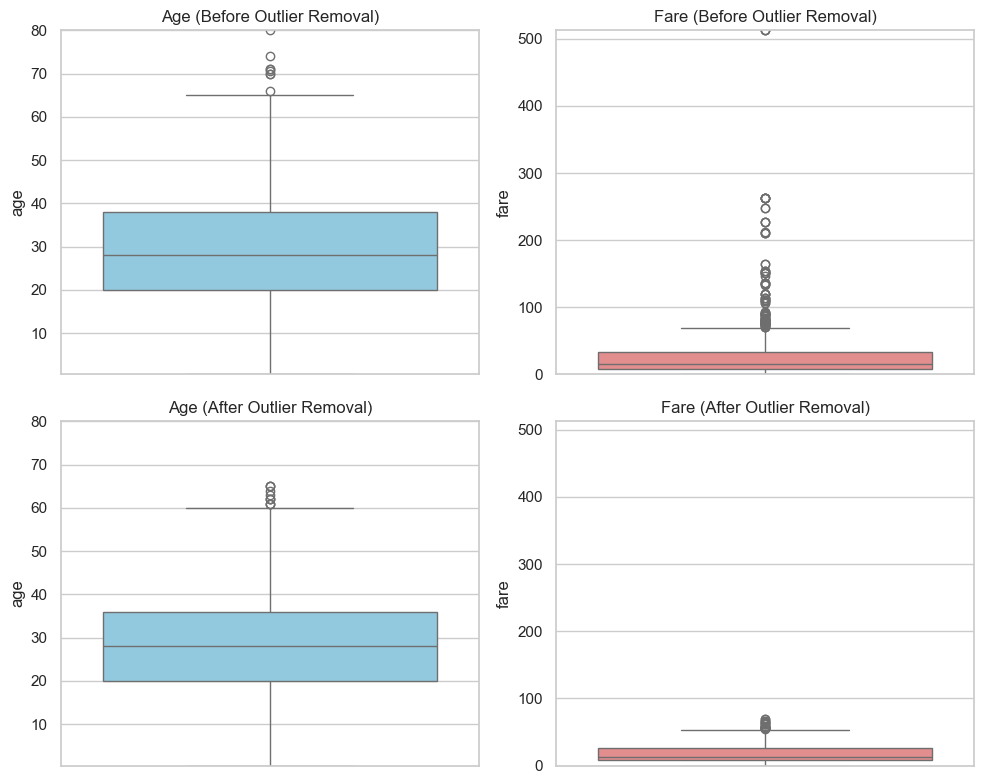

In [19]:
plt.figure(figsize=(10, 8))

# Get common y-limits
age_min = min(titanic_clean['age'].min(), titanic_final['age'].min())
age_max = max(titanic_clean['age'].max(), titanic_final['age'].max())

fare_min = min(titanic_clean['fare'].min(), titanic_final['fare'].min())
fare_max = max(titanic_clean['fare'].max(), titanic_final['fare'].max())

# Before outlier removal boxplots
plt.subplot(2, 2, 1)
sns.boxplot(data=titanic_clean, y='age', color='skyblue')
plt.title('Age (Before Outlier Removal)')
plt.ylim(age_min, age_max)

plt.subplot(2, 2, 2)
sns.boxplot(data=titanic_clean, y='fare', color='lightcoral')
plt.title('Fare (Before Outlier Removal)')
plt.ylim(fare_min, fare_max)

# After outlier removal boxplots
plt.subplot(2, 2, 3)
sns.boxplot(data=titanic_final, y='age', color='skyblue')
plt.title('Age (After Outlier Removal)')
plt.ylim(age_min, age_max)

plt.subplot(2, 2, 4)
sns.boxplot(data=titanic_final, y='fare', color='lightcoral')
plt.title('Fare (After Outlier Removal)')
plt.ylim(fare_min, fare_max)

plt.tight_layout()
plt.show()

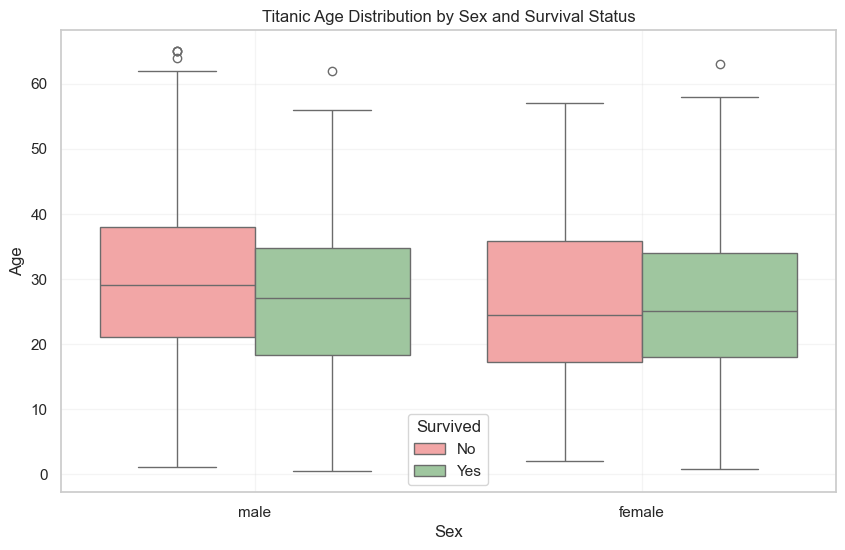

In [20]:
# Titanic age distribution by sex and survival status
plt.figure(figsize=(10, 6))
palette_survived = {0: '#FF9999', 1: '#99CC99'}  # keep colors explicit for No/Yes
sns.boxplot(data=titanic_final, x='sex', y='age', hue='survived', palette=palette_survived)
plt.title('Titanic Age Distribution by Sex and Survival Status')
plt.xlabel('Sex')
plt.ylabel('Age')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['No', 'Yes'], title='Survived')
plt.grid(alpha=0.2)
plt.show()

### Observations from the box plot

- Median age for survivors appears slightly lower compared to non-survivors, especially in males.
- Females show narrower age spread and higher survival proportion (female survivors are much more common from the classic "women and children first" effect).
- Male age distribution for non-survivors includes more older passengers and a higher upper whisker, indicating older males were less likely to survive.
- Children (lower age whisker values) were more likely to survive for both sex categories, matching historical evacuation priority.
- Overall, this confirms sex and age are strong predictors for survival, with females and younger passengers having better outcomes.